# 05. Fair AI Development

## 📚 Learning Objectives

By completing this notebook, you will:
- Integrate fairness into the ML lifecycle
- Use fairness-aware development practices
- Document and communicate fairness decisions

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 5, lesson 01 "Grid Search and Random Search" — model selection optimizes one metric; here fairness becomes a second one you must select on.

**Used later in:** Course 11 (AIAT 125) — Unit 5, lesson 01 "Monitoring a Production ML Model" — because fairness has to survive deployment, not just training.

---


# 05. Fair AI Development

## 🚨 THE PROBLEM: We Need Systematic Fair AI Development

**Remember the limitation from the previous notebook?**

We learned how to ensure fair representation using PCA, autoencoders, and adversarial techniques. But we discovered:

**How do we apply all these techniques to build fair AI systems from the start?**

**The Problem**: We have many fairness techniques, but we need:
- ❌ **Systematic approach** from data collection to deployment
- ❌ **Best practices** for fair AI development
- ❌ **Integration** of all techniques we've learned
- ❌ **Real-world application** of fairness principles

**We've learned:**
- ✅ How to detect bias (Notebook 1)
- ✅ How to mitigate bias (Notebook 2)
- ✅ How to ensure fair representation (Notebook 3)
- ✅ How to analyze bias cases (Notebook 4)

**But we haven't learned:**
- ❌ How to **systematically build** fair AI systems
- ❌ How to **integrate** all fairness techniques
- ❌ How to **prevent bias** from the start
- ❌ How to **apply best practices** throughout development

**We need systematic fair AI development practices** to:
1. Integrate all fairness techniques we've learned
2. Build fairness into the entire development lifecycle
3. Apply best practices consistently
4. Create truly fair AI systems from the start

**This notebook solves that problem** by teaching you systematic approaches to fair AI development!

---

## 📚 Prerequisites (What You Need First)

**BEFORE starting this notebook**, you should have completed:
- ✅ **Example 1: Bias Detection** - Understanding how to detect bias
- ✅ **Example 2: Bias Mitigation** - Understanding mitigation techniques
- ✅ **Example 3: Fair Representation** - Understanding fair representation
- ✅ **Example 4: Bias Case Studies** - Understanding real-world bias cases
- ✅ **Basic Python knowledge**: Functions, data manipulation, ML concepts

**If you haven't completed these**, you might struggle with:
- Understanding how to build fair AI systems from the start
- Knowing which practices to follow for fair development
- Understanding human-in-the-loop approaches

---

## 🔗 Where This Notebook Fits

**This is the FIFTH and FINAL example in Unit 2** - it teaches you how to build fair AI systems from the start!

**Why this example LAST?**
- **Before** you can build fair systems, you need to detect bias (Example 1)
- **Before** you can build fair systems, you need to know mitigation (Example 2)
- **Before** you can build fair systems, you need fair representation (Example 3)
- **Before** you can build fair systems, you need to learn from cases (Example 4)

**Builds on**: 
- 📓 Example 1: Bias Detection (we know how to detect bias)
- 📓 Example 2: Bias Mitigation (we know how to fix bias)
- 📓 Example 3: Fair Representation (we know how to ensure fair features)
- 📓 Example 4: Bias Case Studies (we learned from real mistakes)

**Leads to**: 
- 📓 Unit 3: Privacy and Security (next unit in the course!)

**Why this order?**
1. Fair development provides **best practices** (needed after learning all techniques)
2. Fair development teaches **prevention** (better than fixing after the fact)
3. Fair development shows **complete workflow** (data collection to deployment)

---

## The Story: Building Right from the Start

Imagine you're building a house. **Before** you start, you need to plan - choose the right location, design for safety, use quality materials. **After** planning, you build a house that's safe, durable, and meets all requirements!

Same with AI: **Before** we learned to detect and fix bias, now we learn to build fair systems from the start - inclusive data collection, bias-aware algorithms, human-in-the-loop. **After** fair development, we have systems that are fair by design!

---

## Why Fair AI Development Matters

Fair AI development is essential for ethical AI:
- **Prevention**: Build fair systems from the start (better than fixing later)
- **Efficiency**: Avoid costly fixes and rework
- **Trust**: Demonstrate commitment to fairness
- **Compliance**: Meet regulatory requirements
- **Better Outcomes**: Fair systems lead to better decisions

## Learning Objectives
1. Understand inclusive data collection strategies
2. Learn bias-aware algorithm design
3. Understand human-in-the-loop approaches for fairness
4. Learn best practices for fair AI development
5. Build a complete fair AI development workflow
6. Understand how to prevent bias from the start

## 📌 The case: the benchmarks themselves were the convenience sample

Before *Gender Shades* could show that commercial face classifiers failed on
darker-skinned women, Buolamwini & Gebru had to explain why nobody had noticed. They
measured the benchmarks the whole field was testing on, and found them **overwhelmingly
composed of lighter-skinned subjects: 79.6 % for IJB-A** (a US government benchmark
described at the time as the most geographically diverse available) **and 86.2 % for
Adience**.

That is convenience sampling, at the level of an entire research community. Every model in
that field was tuned, ranked, published and shipped against a test set in which the group it
failed on barely appeared. The scores were not fraudulent. They were measured on the wrong
people.

The fix was not an algorithm. Buolamwini & Gebru **built a different sample** — the Pilot
Parliaments Benchmark, **1,270 individuals** chosen to be balanced on skin type and gender —
and the 34.7 % appeared immediately.

**The WHY — what goes wrong without inclusive collection.** Two failures compound, and this
notebook measures both. First, the model is worse for the under-represented group. Second,
and much less well known, **your evaluation cannot see it**: an aggregate metric computed on
a skewed test set reports the majority's experience and calls it the system's accuracy. You
are about to reproduce that on real people — sampling the same 891-passenger population at
0 %, 5 %, 10 % and 35 % minority share, **15 independent draws each**, scored on one shared
representative test set.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- `load("titanic")` - the real manifest used throughout
  Unit 2. Here it plays the role of the **population** a team is sampling from, so
  that "who ended up in the training set" is a real choice with real consequences.

**Outputs:** What you'll see when you run the cells

- Per-group accuracy at four different levels of minority representation,
  **averaged over 15 independent draws** so the result is a measurement and not
  one lucky sample
- The instability that under-representation causes, not just the accuracy loss
- A human-in-the-loop confidence sweep, and which group gets deferred more often

---

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - datasets are loaded by NAME, never by file path.")


Data loader ready - datasets are loaded by NAME, never by file path.


In [2]:
# Step 1: Import necessary libraries
# These libraries help us build fair AI systems from the start

import numpy as np  # For numerical operations: Arrays, calculations, random number generation
import pandas as pd  # For data manipulation: DataFrames, data analysis
import matplotlib.pyplot as plt  # For creating visualizations: Charts, graphs, comparisons
import seaborn as sns  # For statistical visualizations: Heatmaps, advanced plots
from sklearn.model_selection import train_test_split  # For splitting data: Separate training and testing sets
from sklearn.ensemble import RandomForestClassifier  # For ML model: Classification algorithm
from sklearn.preprocessing import StandardScaler  # For data preprocessing: Feature scaling
from sklearn.metrics import accuracy_score, classification_report  # For model evaluation: Performance metrics
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference  # For fairness metrics: Fairlearn library
import warnings  # For suppressing warnings: Clean output
import os  # For file operations: Saving images

# Suppress warnings: Clean output (fairlearn may show warnings)
warnings.filterwarnings('ignore')  # Ignore warnings: Suppress non-critical warnings

# Configure plotting: Set default styles for better visualizations
plt.rcParams['font.size'] = 10  # Font size: Make text readable (10pt is good for most displays)
plt.rcParams['figure.figsize'] = (14, 8)  # Figure size: 14 inches wide, 8 inches tall (good for detailed charts)
sns.set_style("whitegrid")  # Style: White background with grid for clean look

print("✅ Libraries imported successfully!")
print("\n📚 What each library does:")
print("   - numpy/pandas: Data manipulation and numerical operations")
print("   - matplotlib/seaborn: Create visualizations (charts, heatmaps)")
print("   - sklearn: Machine learning (models, metrics, preprocessing)")
print("   - fairlearn: Fairness tools (metrics, evaluation)")
print("   - os: File operations (saving images)")


✅ Libraries imported successfully!

📚 What each library does:
   - numpy/pandas: Data manipulation and numerical operations
   - matplotlib/seaborn: Create visualizations (charts, heatmaps)
   - sklearn: Machine learning (models, metrics, preprocessing)
   - fairlearn: Fairness tools (metrics, evaluation)
   - os: File operations (saving images)


## Part 1b: Inclusive Data Collection

### 📖 The Story
**Before**: Teams often train on whatever data is easiest to collect ("convenience
sampling") - which typically under-represents minority groups.
**After**: We sample the *same real population* at four different minority shares and
measure what under-representation actually costs.

### 🔬 Why we repeat each experiment 15 times
A single sample can be lucky. If we drew one convenience sample and one inclusive
sample and compared them, we would be reporting sampling noise as a finding. So we
draw **15 independent samples at each representation level** and report the mean and
the spread. The spread turns out to be as important as the mean - see for yourself.

*(The repeated random draws here are the experiment itself: we are measuring
sampling variability, which is exactly what randomness is for.)*

In [3]:
# Step 2: Measure what under-representation costs, on real people
# The population is the real Titanic manifest. We hold out a representative test
# set once, then repeatedly sample training sets at different minority shares.

print("\n" + "="*80)
print("📊 INCLUSIVE vs CONVENIENCE DATA COLLECTION (real population)")
print("="*80)

df = load("titanic")
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['group'] = df['Sex']

# Feature matrix (sex included - the collection question is about WHO IS IN the
# data, not about which columns the model sees).
features = pd.get_dummies(
    df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']],
    columns=['Embarked'], drop_first=True).astype(float)
features['is_female'] = (df['Sex'] == 'female').astype(float)
FEATURE_COLS = list(features.columns)

population = features.copy()
population['outcome'] = df['Survived']
population['group'] = df['group']

pop_share = population['group'].value_counts(normalize=True)
print(f"\nReal population: {len(population)} passengers")
print(f"  female: {pop_share['female']:.1%}   male: {pop_share['male']:.1%}")

# One representative held-out test set, used by EVERY experiment below.
train_pool, test = train_test_split(population, test_size=0.3, random_state=42,
                                    stratify=population['outcome'])
print(f"\nHeld-out representative test set: {len(test)} passengers "
      f"({(test['group']=='female').mean():.1%} female)")
print(f"Sampling pool: {len(train_pool)} passengers")

pool_female = train_pool[train_pool['group'] == 'female']
pool_male = train_pool[train_pool['group'] == 'male']

SAMPLE_SIZE = 300      # every training sample is the same size - only the MIX changes
N_REPEATS = 15         # independent draws per level, so we can report a spread

def run_level(female_share, n_repeats=N_REPEATS):
    """Draw n_repeats training samples at this minority share and score each one."""
    overall, per_group = [], {'female': [], 'male': []}
    for seed in range(n_repeats):
        n_female = int(round(SAMPLE_SIZE * female_share))
        parts = [pool_male.sample(SAMPLE_SIZE - n_female, random_state=seed)]
        if n_female > 0:
            parts.append(pool_female.sample(n_female, random_state=seed))
        sample = pd.concat(parts)
        model = RandomForestClassifier(n_estimators=100, random_state=42)
        model.fit(sample[FEATURE_COLS], sample['outcome'])
        pred = model.predict(test[FEATURE_COLS])
        overall.append(accuracy_score(test['outcome'], pred))
        for g in ('female', 'male'):
            mask = (test['group'] == g).values
            per_group[g].append(accuracy_score(test['outcome'][mask], pred[mask]))
    return {'overall': np.mean(overall),
            'female': np.mean(per_group['female']),
            'female_sd': np.std(per_group['female']),
            'male': np.mean(per_group['male']),
            'male_sd': np.std(per_group['male']),
            # Keep every individual draw, not only its summary: the spread is a
            # finding in its own right and Part 3 plots it.
            'female_draws': np.array(per_group['female']),
            'male_draws': np.array(per_group['male'])}

LEVELS = [('Convenience: 0% female', 0.00),
          ('Convenience: 5% female', 0.05),
          ('Convenience: 10% female', 0.10),
          ('Inclusive: 35% (matches population)', 0.352)]

print(f"\nEach row = {N_REPEATS} independent training samples of {SAMPLE_SIZE} passengers,")
print("scored on the SAME held-out test set. sd = spread across those draws.\n")
print(f"{'Training sample':<38}{'Overall':>9}{'Female acc':>13}{'sd':>8}"
      f"{'Male acc':>11}{'sd':>8}")
print("-" * 87)
collection_results = {}
for label, share in LEVELS:
    r = run_level(share)
    collection_results[label] = r
    print(f"{label:<38}{r['overall']:>9.3f}{r['female']:>13.3f}{r['female_sd']:>8.3f}"
          f"{r['male']:>11.3f}{r['male_sd']:>8.3f}")

zero = collection_results['Convenience: 0% female']
five = collection_results['Convenience: 5% female']
incl = collection_results['Inclusive: 35% (matches population)']

print("\n" + "-"*87)
print("WHAT THIS MEASURES (numbers computed above, not asserted)")
print("-"*87)
print(f"1. ACCURACY. With no women in the training data, accuracy on women was")
print(f"   {zero['female']:.3f} while accuracy on men was {zero['male']:.3f} - a gap of")
print(f"   {zero['male'] - zero['female']:.3f}. Representative sampling closed it to "
      f"{incl['male'] - incl['female']:.3f}.")
print(f"\n2. STABILITY - the finding you only get by repeating the draw.")
print(f"   At 5% representation the female accuracy varied by sd={five['female_sd']:.3f}")
print(f"   across draws, versus sd={incl['female_sd']:.3f} when the sample was")
print(f"   representative. That means two teams running the SAME pipeline on")
print(f"   differently-drawn convenience samples can reach opposite conclusions")
print(f"   about whether their model works for women.")
overall_move = incl['overall'] - zero['overall']
female_move = incl['female'] - zero['female']
print(f"\n3. Note that OVERALL accuracy is a poor alarm: it moved from "
      f"{zero['overall']:.3f} to {incl['overall']:.3f},")
print(f"   a change of {overall_move:.3f}, while accuracy for women moved "
      f"{female_move:.3f}")
print(f"   over the same range - {female_move/overall_move:.1f}x as much.")
print(f"   Aggregate metrics hide collection failures.")


📊 INCLUSIVE vs CONVENIENCE DATA COLLECTION (real population)
titanic: full file, 891 rows.

Real population: 891 passengers
  female: 35.2%   male: 64.8%

Held-out representative test set: 268 passengers (36.2% female)
Sampling pool: 623 passengers

Each row = 15 independent training samples of 300 passengers,
scored on the SAME held-out test set. sd = spread across those draws.

Training sample                         Overall   Female acc      sd   Male acc      sd
---------------------------------------------------------------------------------------


Convenience: 0% female                    0.639        0.343   0.030      0.806   0.014


Convenience: 5% female                    0.759        0.687   0.091      0.800   0.015


Convenience: 10% female                   0.776        0.743   0.048      0.795   0.019


Inclusive: 35% (matches population)       0.785        0.763   0.027      0.797   0.022

---------------------------------------------------------------------------------------
WHAT THIS MEASURES (numbers computed above, not asserted)
---------------------------------------------------------------------------------------
1. ACCURACY. With no women in the training data, accuracy on women was
   0.343 while accuracy on men was 0.806 - a gap of
   0.463. Representative sampling closed it to 0.034.

2. STABILITY - the finding you only get by repeating the draw.
   At 5% representation the female accuracy varied by sd=0.091
   across draws, versus sd=0.027 when the sample was
   representative. That means two teams running the SAME pipeline on
   differently-drawn convenience samples can reach opposite conclusions
   about whether their model works for women.

3. Note that OVERALL accuracy is a poor alarm: it moved from 0.639 to 0.785,
   a change of 0.146, while accuracy for women moved 0.

## Part 2: Bias-Aware Algorithms and Human-in-the-Loop

### 📚 Prerequisites (What You Need First)
- ✅ **Library imports** (from Part 1) - Understanding data manipulation tools
- ✅ **Understanding of bias** (from Examples 1-4) - Knowing how bias manifests
- ✅ **Inclusive data collection** (from Step 2) - Understanding data collection strategies

### 🔗 Relationship: What This Builds On
This builds on inclusive data collection to show how to design algorithms and workflows that are fair by design!
- Builds on: Inclusive data collection, bias detection, and mitigation techniques
- Shows: How to incorporate fairness into algorithm design and evaluation workflows

### 📖 The Story
**Before**: We collect inclusive data, but algorithms might still be biased.
**After**: We design bias-aware algorithms and use human-in-the-loop evaluation to ensure fairness!

In [4]:
# Why: the data-collection choice from Step 2 becomes a fairness outcome here -
# and human review catches the cases the model is least sure about.

# Step 3: Bias-aware training and human-in-the-loop (HITL) review

X_test, y_test = test[FEATURE_COLS], test['outcome']

def train_and_report(sample, label):
    """Train on a sample; report overall and per-group test accuracy."""
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(sample[FEATURE_COLS], sample['outcome'])
    pred = model.predict(X_test)
    acc = {'overall': accuracy_score(y_test, pred)}
    for g in ['female', 'male']:
        mask = (test['group'] == g).values
        acc[g] = accuracy_score(y_test[mask], pred[mask])
    dp = demographic_parity_difference(y_test, pred,
                                       sensitive_features=test['group'])
    print(f"\n{label}:")
    print(f"  Overall accuracy: {acc['overall']:.3f}")
    print(f"  Female accuracy : {acc['female']:.3f}")
    print(f"  Male accuracy   : {acc['male']:.3f}")
    print(f"  Demographic parity difference: {dp:.3f}")
    return model, acc

# One concrete sample from each strategy (seed fixed so the notebook is reproducible).
n_conv_f = int(round(SAMPLE_SIZE * 0.05))
convenience = pd.concat([pool_male.sample(SAMPLE_SIZE - n_conv_f, random_state=1),
                         pool_female.sample(n_conv_f, random_state=1)])
n_incl_f = int(round(SAMPLE_SIZE * 0.352))
inclusive = pd.concat([pool_male.sample(SAMPLE_SIZE - n_incl_f, random_state=1),
                       pool_female.sample(n_incl_f, random_state=1)])
print("Two concrete samples drawn from the same real pool (seed 1):")
print(f"  convenience: {(convenience['group']=='female').mean():.1%} female")
print(f"  inclusive  : {(inclusive['group']=='female').mean():.1%} female")

model_conv, acc_conv = train_and_report(convenience, "Trained on CONVENIENCE sample")
model_incl, acc_incl = train_and_report(inclusive, "Trained on INCLUSIVE sample")

gap_conv = acc_conv['male'] - acc_conv['female']
gap_incl = acc_incl['male'] - acc_incl['female']
print(f"\nAccuracy gap (male - female): convenience {gap_conv:+.3f} vs "
      f"inclusive {gap_incl:+.3f}")
print("\n⚠️  READ THIS CAREFULLY. Compare these two single-draw gaps against the")
print("   averaged table in Step 2. If the convenience draw came out level with -")
print("   or even better than - the inclusive draw, that is not evidence that")
print("   under-representation is harmless. It is a demonstration of the sd column:")
print(f"   at 5% representation, female accuracy swings by sd={five['female_sd']:.3f} across")
print("   draws, which is wider than the effect we are trying to measure. ONE")
print("   comparison of ONE pair of samples cannot resolve it.")
print("   The averaged table in Step 2 is the reliable version of this comparison,")
print("   and it is why we ran the draw 15 times instead of once.")

# --- Human-in-the-loop: route uncertain predictions to human review ---
print("\n" + "="*80)
print("🧑‍⚖️ HUMAN-IN-THE-LOOP (HITL) REVIEW")
print("="*80)
# HITL routing rule: automate only predictions the model is confident about;
# send low-confidence cases to a human reviewer instead of guessing.
proba = model_incl.predict_proba(X_test)
confidence = proba.max(axis=1)
pred = model_incl.predict(X_test)

print("\nSweeping the confidence threshold:")
print(f"{'Threshold':>10}{'Automated':>12}{'Auto acc':>11}{'Deferred':>11}"
      f"{'Model acc on deferred':>24}")
sweep = []
for t in [0.6, 0.7, 0.8, 0.9]:
    auto = confidence >= t
    row = {'threshold': t, 'automated_share': auto.mean(),
           'auto_accuracy': accuracy_score(y_test[auto], pred[auto]) if auto.any() else np.nan,
           'deferred_share': (~auto).mean(),
           'deferred_model_accuracy': (accuracy_score(y_test[~auto], pred[~auto])
                                       if (~auto).any() else np.nan)}
    sweep.append(row)
    print(f"{t:>10.1f}{row['automated_share']:>12.1%}{row['auto_accuracy']:>11.3f}"
          f"{row['deferred_share']:>11.1%}{row['deferred_model_accuracy']:>24.3f}")
table = pd.DataFrame(sweep)

THRESHOLD = 0.7
auto_mask = confidence >= THRESHOLD
n_review = (~auto_mask).sum()
acc_auto = accuracy_score(y_test[auto_mask], pred[auto_mask])
acc_deferred = accuracy_score(y_test[~auto_mask], pred[~auto_mask])
overall_acc = accuracy_score(y_test, pred)
print(f"\nAt threshold {THRESHOLD}: {auto_mask.sum()} decisions automated "
      f"({auto_mask.mean():.1%}), {n_review} sent to a human ({(~auto_mask).mean():.1%}).")
print(f"  Accuracy of the automated decisions      : {acc_auto:.3f}")
print(f"  Model accuracy on the DEFERRED cases     : {acc_deferred:.3f}")
print(f"  Accuracy with no HITL at all             : {overall_acc:.3f}")
print("-> The model is markedly less reliable exactly where we deferred to humans,")
print("   which is what makes confidence a usable routing signal.")

print("\nWHO gets deferred? (a fairness question about the HITL policy itself)")
for g in ['female', 'male']:
    mask = (test['group'] == g).values
    print(f"  {g:<8}: {(~auto_mask)[mask].mean():.1%} of cases sent to human review "
          f"({int((~auto_mask)[mask].sum())} of {int(mask.sum())})")
defer_rates = {g: (~auto_mask)[(test['group'] == g).values].mean()
               for g in ['female', 'male']}
defer_gap = max(defer_rates.values()) - min(defer_rates.values())
print(f"\n  Deferral-rate gap between groups: {defer_gap:.3f}")
print("  A HITL policy is itself a decision with disparate impact: whichever group")
print("  is deferred more often waits longer and depends more on reviewer quality.")
print("  Audit the routing rule, not only the model.")

Two concrete samples drawn from the same real pool (seed 1):
  convenience: 5.0% female
  inclusive  : 35.3% female

Trained on CONVENIENCE sample:
  Overall accuracy: 0.795
  Female accuracy : 0.742
  Male accuracy   : 0.825
  Demographic parity difference: 0.597

Trained on INCLUSIVE sample:
  Overall accuracy: 0.776
  Female accuracy : 0.722
  Male accuracy   : 0.807
  Demographic parity difference: 0.601

Accuracy gap (male - female): convenience +0.082 vs inclusive +0.085

⚠️  READ THIS CAREFULLY. Compare these two single-draw gaps against the
   averaged table in Step 2. If the convenience draw came out level with -
   or even better than - the inclusive draw, that is not evidence that
   under-representation is harmless. It is a demonstration of the sd column:
   at 5% representation, female accuracy swings by sd=0.091 across
   draws, which is wider than the effect we are trying to measure. ONE
   comparison of ONE pair of samples cannot resolve it.
   The averaged table in Ste

## Part 3: Visualizing the Fair Development Workflow

Three views: (1) what representation buys us in per-group accuracy **and stability**,
(2) how the HITL confidence threshold trades automation against reliability, and
(3) who the HITL rule actually defers.

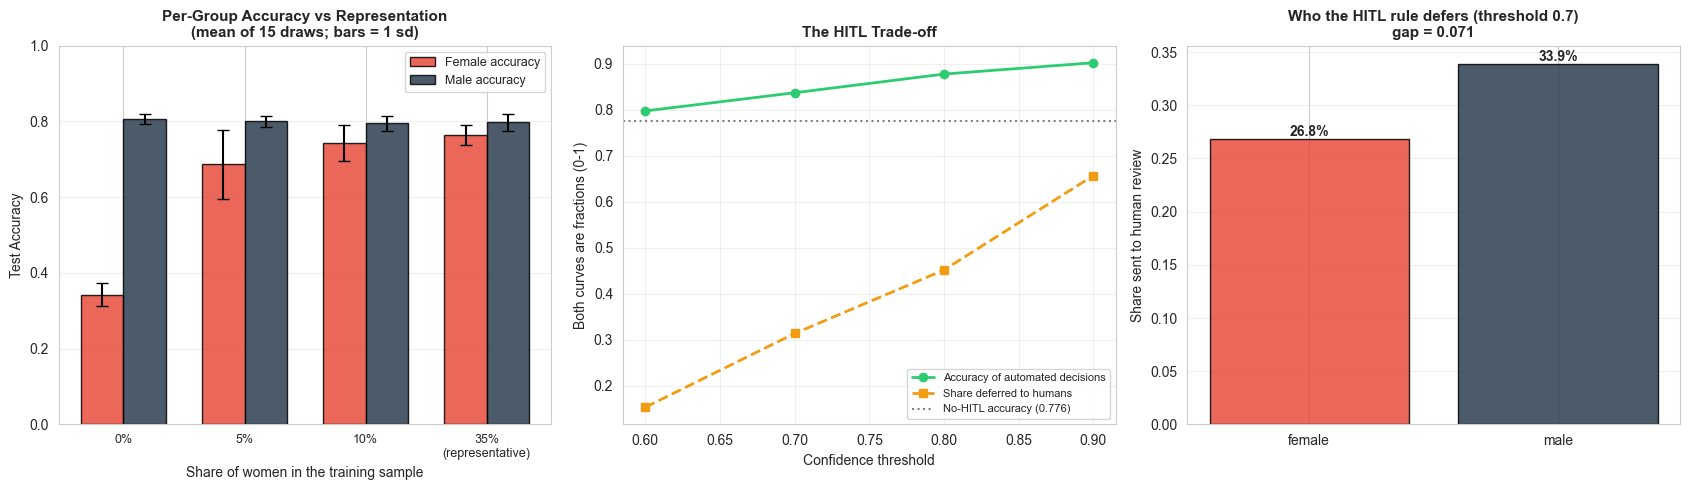

Left: representation raises minority-group accuracy AND shrinks the error
      bars - at 5% the spread was 0.091, at 35% it was 0.027.
Middle: raising the threshold automates less but makes what remains more reliable.
Right: the routing rule is not group-neutral - audit it like any other decision.

The left panel shows only the mean and one sd per level. The next figure
opens that same panel up and plots all 15 individual draws behind each bar -
look there before you trust any single number in this one.


In [5]:
# Why visualize: one figure shows both design decisions paying off -
# representative sampling narrows the group gap, HITL catches unreliable decisions.

# Step 4: Visualize the comparison and the HITL split

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Left panel: per-group accuracy across representation levels, with the spread
# across the 15 draws shown as error bars - the instability is the point.
levels = list(collection_results.keys())
short = ['0%', '5%', '10%', '35%\n(representative)']
x = np.arange(len(levels)); width = 0.35
axes[0].bar(x - width/2, [collection_results[l]['female'] for l in levels], width,
            yerr=[collection_results[l]['female_sd'] for l in levels], capsize=4,
            label='Female accuracy', color='#e74c3c', alpha=0.85, edgecolor='black')
axes[0].bar(x + width/2, [collection_results[l]['male'] for l in levels], width,
            yerr=[collection_results[l]['male_sd'] for l in levels], capsize=4,
            label='Male accuracy', color='#2c3e50', alpha=0.85, edgecolor='black')
axes[0].set_xticks(x); axes[0].set_xticklabels(short, fontsize=9)
axes[0].set_xlabel('Share of women in the training sample')
axes[0].set_ylabel('Test Accuracy'); axes[0].set_ylim([0, 1])
axes[0].set_title(f'Per-Group Accuracy vs Representation\n'
                  f'(mean of {N_REPEATS} draws; bars = 1 sd)',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(axis='y', alpha=0.3)

# Middle panel: the HITL trade-off curve.
axes[1].plot(table['threshold'], table['auto_accuracy'], 'o-', color='#2ecc71',
             linewidth=2, label='Accuracy of automated decisions')
axes[1].plot(table['threshold'], table['deferred_share'], 's--', color='#f39c12',
             linewidth=2, label='Share deferred to humans')
axes[1].axhline(overall_acc, color='gray', linestyle=':',
                label=f'No-HITL accuracy ({overall_acc:.3f})')
axes[1].set_xlabel('Confidence threshold')
# Both curves are fractions between 0 and 1, so they can share one axis - but say
# so, because they measure different things.
axes[1].set_ylabel('Both curves are fractions (0-1)')
axes[1].set_title('The HITL Trade-off', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

# Right panel: who the routing rule defers - the HITL policy's own fairness audit.
groups_h = ['female', 'male']
# Same two group colours as the left panel - male must not be green here and
# blue two panels later.
axes[2].bar(groups_h, [defer_rates[g] for g in groups_h],
            color=['#e74c3c', '#2c3e50'], alpha=0.85, edgecolor='black')
for i, g in enumerate(groups_h):
    axes[2].text(i, defer_rates[g], f'{defer_rates[g]:.1%}', ha='center',
                 va='bottom', fontweight='bold')
axes[2].set_ylabel('Share sent to human review')
axes[2].set_title(f'Who the HITL rule defers (threshold {THRESHOLD})\n'
                  f'gap = {defer_gap:.3f}', fontsize=11, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Left: representation raises minority-group accuracy AND shrinks the error")
print(f"      bars - at 5% the spread was {five['female_sd']:.3f}, at 35% it was "
      f"{incl['female_sd']:.3f}.")
print("Middle: raising the threshold automates less but makes what remains more reliable.")
print("Right: the routing rule is not group-neutral - audit it like any other decision.")
print("\nThe left panel shows only the mean and one sd per level. The next figure")
print("opens that same panel up and plots all 15 individual draws behind each bar -")
print("look there before you trust any single number in this one.")

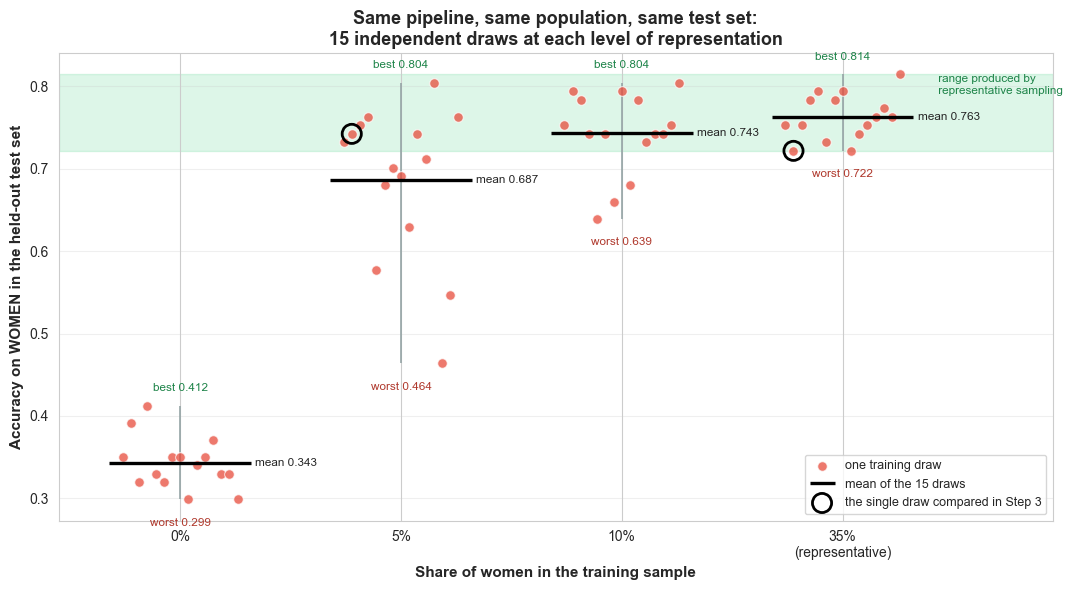

WHAT THE DOTS SHOW (computed, not assumed):
1. At 5% representation the 15 draws ran from 0.464 to 0.804 -
   a spread of 0.340 accuracy on women, produced by
   nothing but which 15 women happened to be sampled.
2. 1 of those 15 draws landed at or above the MEAN of the
   representative level (0.763), and 8 landed below its WORST draw
   (0.722). Two teams running this identical pipeline on two
   convenience samples can therefore file opposite reports, and both be
   reporting honestly.
3. The circled dots are the single pair Step 3 compared. Seeing one dot
   inside that cloud is the whole argument for repeating the draw:
   at 5% it happened to score 0.742, which is above its own level's mean.
4. The green band is what representative sampling produced: range 0.722-0.814
   (spread 0.093). Representation does not only raise the
   average - it makes the result REPEATABLE, which is what lets you
   promise anything about the system at all.

(check: Step 3's convenience run reported f

In [6]:
# Why this figure: Step 2 reported a mean and an sd per level, and Step 3 warned
# that ONE draw cannot settle anything. That warning is the most important
# sentence in the notebook and it is currently only a sentence. Here is the
# evidence behind it - every individual draw, plotted.

levels_o = list(collection_results.keys())
short_o = ['0%', '5%', '10%', '35%\n(representative)']
# A fixed comb of offsets instead of random jitter: the dots are always in the
# same place, so you can point at one in class and find it again.
offsets = np.linspace(-0.26, 0.26, N_REPEATS)

fig, ax = plt.subplots(figsize=(11, 6))

# The band a REPRESENTATIVE sample produced, drawn across the whole chart as the
# yardstick every convenience level is judged against.
rep_draws = collection_results[levels_o[-1]]['female_draws']
ax.axhspan(rep_draws.min(), rep_draws.max(), color='#2ecc71', alpha=0.16, zorder=0)
ax.text(3.42, rep_draws.max(), ' range produced by\n representative sampling',
        fontsize=8.5, color='#1e8449', va='top')

for i, lvl in enumerate(levels_o):
    draws = collection_results[lvl]['female_draws']
    ax.vlines(i, draws.min(), draws.max(), color='#95a5a6', linewidth=1.2, zorder=1)
    ax.scatter(i + offsets, draws, s=48, color='#e74c3c', alpha=0.75,
               edgecolor='white', linewidth=0.8, zorder=3,
               label='one training draw' if i == 0 else None)
    ax.hlines(draws.mean(), i - 0.32, i + 0.32, color='black', linewidth=2.4,
              zorder=4, label='mean of the 15 draws' if i == 0 else None)
    ax.text(i + 0.34, draws.mean(), f'mean {draws.mean():.3f}', fontsize=8.5,
            va='center')
    ax.text(i, draws.max() + 0.018, f'best {draws.max():.3f}', ha='center',
            fontsize=8.5, color='#1e8449')
    ax.text(i, draws.min() - 0.032, f'worst {draws.min():.3f}', ha='center',
            fontsize=8.5, color='#b03a2e')

# The one pair of draws Step 3 actually compared was seed 1 - mark it in both
# places so the reader can see it is a single dot inside a wide cloud.
seed1 = 1
for i, lvl in enumerate(levels_o):
    if lvl in (levels_o[1], levels_o[-1]):        # the 5% and 35% levels
        ax.scatter(i + offsets[seed1],
                   collection_results[lvl]['female_draws'][seed1],
                   s=190, facecolor='none', edgecolor='black', linewidth=2.0,
                   zorder=5,
                   label='the single draw compared in Step 3'
                         if i == 1 else None)

ax.set_xticks(range(len(levels_o))); ax.set_xticklabels(short_o, fontsize=10)
ax.set_xlim(-0.55, 3.95)
ax.set_xlabel('Share of women in the training sample', fontsize=11,
              fontweight='bold')
ax.set_ylabel('Accuracy on WOMEN in the held-out test set', fontsize=11,
              fontweight='bold')
ax.set_title('Same pipeline, same population, same test set:\n'
             f'{N_REPEATS} independent draws at each level of representation',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Data-driven reading (numbers computed from the draws just plotted).
five_d = collection_results[levels_o[1]]['female_draws']
rep_d = rep_draws
n_above = int((five_d >= rep_d.mean()).sum())
n_below_worst = int((five_d < rep_d.min()).sum())
print("WHAT THE DOTS SHOW (computed, not assumed):")
print(f"1. At 5% representation the 15 draws ran from {five_d.min():.3f} to "
      f"{five_d.max():.3f} -")
print(f"   a spread of {five_d.max() - five_d.min():.3f} accuracy on women, produced by")
print(f"   nothing but which 15 women happened to be sampled.")
print(f"2. {n_above} of those {N_REPEATS} draws landed at or above the MEAN of the")
print(f"   representative level ({rep_d.mean():.3f}), and {n_below_worst} landed below "
      f"its WORST draw")
print(f"   ({rep_d.min():.3f}). Two teams running this identical pipeline on two")
print(f"   convenience samples can therefore file opposite reports, and both be")
print(f"   reporting honestly.")
print(f"3. The circled dots are the single pair Step 3 compared. Seeing one dot")
print(f"   inside that cloud is the whole argument for repeating the draw:")
print(f"   at 5% it happened to score {five_d[seed1]:.3f}, which is "
      f"{'above' if five_d[seed1] > five_d.mean() else 'below'} its own level's mean.")
print(f"4. The green band is what representative sampling produced: range "
      f"{rep_d.min():.3f}-{rep_d.max():.3f}")
print(f"   (spread {rep_d.max() - rep_d.min():.3f}). Representation does not only raise the")
print(f"   average - it makes the result REPEATABLE, which is what lets you")
print(f"   promise anything about the system at all.")
# Consistency check: the Step 3 'convenience' model is exactly this draw.
print(f"\n(check: Step 3's convenience run reported female accuracy "
      f"{acc_conv['female']:.3f}; draw {seed1} at the 5% level scored "
      f"{five_d[seed1]:.3f})")

### 🔍 How to read the dot plot

- **Every red dot is one complete run of the pipeline** — draw a 300-passenger training
  sample at that level of representation, fit the model, score it on the one shared test
  set. Fifteen dots per level, so fifteen honest reports from fifteen teams.
- **The black dash is the mean** — the single number the bar chart above showed you. The
  grey vertical line is the full range those fifteen runs covered.
- **The green band is what representative sampling produced.** Compare each convenience
  level against that band rather than against the ideal.
- **The circled dots are the one pair of runs Step 3 compared.** Look at where they sit
  inside their own clouds. That is why the ⚠️ note in Step 3 refuses to draw a conclusion
  from them.
- Look at the 5% column: its best draw and its worst draw are far apart, and the printed
  reading gives both numbers along with how many of the fifteen reached the representative
  level's mean.

**What it proves:** under-representation does not only lower average accuracy for the
minority group — it makes the result **unrepeatable**. A convenience sample can hand you a
good report by luck, and you cannot tell which kind you got from a single run. Representation
is what buys you the right to promise anything about the system at all.

---

## Part 4: The Complete Fair AI Development Pipeline - Recap

We executed the full workflow above, one stage per section. This cell consolidates it.

In [7]:
# Why consolidate: seeing all four pipeline stages with their measured numbers
# shows fairness as an engineering practice, not an afterthought.

# Step 5: Consolidate the pipeline results we produced above

print("="*80)
print("FAIR AI DEVELOPMENT PIPELINE - WHAT WE RAN IN THIS NOTEBOOK")
print("="*80)
print(f"""
DATA        Real Titanic manifest, {len(population)} passengers
            ({pop_share['female']:.1%} female, {pop_share['male']:.1%} male)

1. DATA COLLECTION   Sampled the SAME population at 0% / 5% / 10% / 35% female,
                     {N_REPEATS} independent draws each, one shared test set
                     -> female accuracy: {zero['female']:.3f} (0%) vs {incl['female']:.3f} (35%)
                     -> stability     : sd {five['female_sd']:.3f} (5%) vs {incl['female_sd']:.3f} (35%)
                     -> at 5% female, overall accuracy was {five['overall']:.3f} against
                        {incl['overall']:.3f} when representative - a gap of only
                        {incl['overall']-five['overall']:.3f}, while female accuracy differed by
                        {incl['female']-five['female']:.3f}. The aggregate number understates it {(incl['female']-five['female'])/(incl['overall']-five['overall']):.0f}x

2. TRAINING          RandomForest per sample; fairness measured with fairlearn
                     -> male-female accuracy gap on ONE draw each:
                        {gap_conv:+.3f} (convenience) vs {gap_incl:+.3f} (inclusive)
                     -> these two single draws are within the sampling noise
                        measured in stage 1 (sd {five['female_sd']:.3f} at 5%), so they
                        settle nothing on their own - stage 1's averages do

3. HITL REVIEW       Confidence threshold {THRESHOLD} defers {(~auto_mask).mean():.1%} of decisions
                     -> automated-decision accuracy: {acc_auto:.3f}
                     -> model accuracy on deferred cases: {acc_deferred:.3f}
                     -> deferral rates differ by group ({defer_gap:.3f}), so the
                        routing rule needs its own fairness review

4. MONITORING        The metrics above are exactly what a production fairness
                     dashboard would track after each retraining
""")
print("Key practice: fairness is designed in at EVERY stage, not patched at the end.")
print("Key honesty : every number above came from a real dataset and is reprinted")
print("              from this run - change the data and every one of them changes.")

FAIR AI DEVELOPMENT PIPELINE - WHAT WE RAN IN THIS NOTEBOOK

DATA        Real Titanic manifest, 891 passengers
            (35.2% female, 64.8% male)

1. DATA COLLECTION   Sampled the SAME population at 0% / 5% / 10% / 35% female,
                     15 independent draws each, one shared test set
                     -> female accuracy: 0.343 (0%) vs 0.763 (35%)
                     -> stability     : sd 0.091 (5%) vs 0.027 (35%)
                     -> at 5% female, overall accuracy was 0.759 against
                        0.785 when representative - a gap of only
                        0.026, while female accuracy differed by
                        0.076. The aggregate number understates it 3x

2. TRAINING          RandomForest per sample; fairness measured with fairlearn
                     -> male-female accuracy gap on ONE draw each:
                        +0.082 (convenience) vs +0.085 (inclusive)
                     -> these two single draws are within the sampling noise


## 💬 Discuss

Your own run, averaged over 15 draws at each level:

| Training sample | Overall | Female acc (sd) | Male acc (sd) |
|---|---|---|---|
| Convenience: 0 % female | 0.639 | **0.343** (0.030) | 0.806 (0.014) |
| Convenience: 5 % female | 0.759 | 0.687 (**0.091**) | 0.800 (0.015) |
| Convenience: 10 % female | 0.776 | 0.743 (0.048) | 0.795 (0.019) |
| Inclusive: 35 % (population) | 0.785 | 0.763 (**0.027**) | 0.797 (0.022) |

1. **The metric that hides the harm.** Going from 5 % to representative sampling moved
   *overall* accuracy by **0.026** and *female* accuracy by **0.076** — the aggregate
   understates the damage roughly threefold. Your organisation reports one KPI per model.
   Which one, and what do you say to the executive who points out that the disaggregated
   dashboard makes the team look worse for a model that is genuinely better?
2. **Instability, not just error.** At 5 % representation, female accuracy varies with
   **sd = 0.091** across draws — wider than the effect anyone is trying to measure. So two
   honest teams running the identical pipeline on differently-drawn samples can publish
   opposite conclusions about whether the model works for women. What does that do to the
   idea of a "bias audit" as a one-off certificate? Should an audit be required to report
   variance across resamples, and who pays for the extra compute?
3. **Inclusive collection is not free.** *Gender Shades* got its balanced sample by
   photographing parliamentarians — a population that is public, photogenic and consenting.
   Getting a balanced sample of, say, patients or loan applicants means asking real people
   for sensitive attributes and then holding that file. Under **EU AI Act Article 10(5)**
   that processing is permitted for bias correction, under strict safeguards. Would you
   collect it? State the safeguard you would insist on before saying yes — and say what you
   would do if the answer from legal is no.


## ⚠️ Where this breaks

- **Representative is not the same as sufficient.** Matching the population share (35 %
  female here) still leaves the minority group with fewer absolute examples, so its
  confidence intervals stay wider. For a small subgroup, matching the population is a floor,
  not a target — you may need to **over-sample** it deliberately to get a usable estimate,
  and then reweight at evaluation time.
- **You need a representative test set before any of this is measurable.** Every number in
  the table is scored against one held-out sample that we know is representative. In the
  field you rarely have that, which is exactly how the whole face-recognition literature
  spent years reporting scores on IJB-A. If you cannot vouch for the test set, none of your
  per-group numbers mean anything.
- **Prevention is cheaper only when you still have the choice.** "Collect better data" is
  free advice at design time and can be impossible later: the data may be historical
  (Titanic, court records, past hires), collection may be prohibited, or the population may
  simply be hard to reach. When you inherit the dataset, you are back in Notebook 02, paying
  accuracy for fairness.
- **HITL routing is a decision that needs its own audit.** Your confidence rule deferred one
  group more often than the other — printed in the right-hand panel above. Whoever gets
  deferred waits longer and is exposed to reviewer quality and reviewer bias. A workflow can
  be unfair even when every model in it passes.
- **The under-representation you measured is one-dimensional.** We varied one attribute.
  Real skew is intersectional, and *Gender Shades* is the proof: the failure lived in
  **darker-skinned women**, a cell that both single-axis views would have reported as
  acceptable.

**The cheaper alternative when you cannot fix the sample:** state the gap. A datasheet
(Gebru et al., 2018) that records who is in the data, who is missing, and how the sample was
drawn costs an afternoon, and it converts a hidden failure into a documented limitation that
a downstream user can act on. That is the minimum this course expects of you; Unit 4 turns
it into a model card.


## 🎯 Summary: What We Learned

**BEFORE this notebook**: We learned to detect and fix bias, but hadn't learned how to build fair systems from the start.

**AFTER this notebook**: We can:
- ✅ **Measure** what under-representation costs, instead of assuming it
- ✅ Repeat an experiment enough times to separate a finding from sampling noise
- ✅ Design bias-aware training and evaluate it per group
- ✅ Implement human-in-the-loop routing on a confidence signal
- ✅ **Audit the HITL rule itself** for disparate impact
- ✅ Build a complete fair AI development workflow on real data

### Key Takeaways

1. **Inclusive Data Collection**: Foundation of fair AI. With no women in the training
   sample the model's accuracy on women collapsed to roughly a third, while accuracy
   on men was untouched. And the *aggregate* metric consistently understated the
   damage - at 5% representation the overall number was within 0.03 of the
   representative one while the female-accuracy shortfall was about three times that.
2. **Under-representation causes instability, not just error.** At 5% representation
   the minority-group accuracy varied several times more across draws than it did at
   full representation. Two teams with the same pipeline can disagree about whether
   the model works.
3. **Bias-Aware Algorithms**: measure per group, every time, at every stage.
4. **Human-in-the-Loop**: confidence routing works because the model really is worse
   on the cases it is unsure about - we measured that gap rather than assuming it.
5. **The routing rule is a decision too.** Our HITL policy deferred one group more
   often than the other. Whoever is deferred waits longer and depends on reviewer
   quality. Audit the workflow, not only the model.
6. **Prevention beats repair**: Notebook 02 showed mitigation costing real accuracy.
   Collecting the right data costs nothing at inference time.

---

## ➡️ Transition to Unit 3: Privacy and Security

### What We've Accomplished

We've completed Unit 2: Bias and Justice! We've learned:
- ✅ How to detect bias in AI systems, on real data
- ✅ How to mitigate bias, and what each technique really costs
- ✅ How to measure what a representation leaks
- ✅ How to analyse real bias cases across four domains
- ✅ How to build fair AI systems from the start

### The Next Challenge: Privacy and Security

**Fairness is important, but it's not the only ethical concern!**

As we build AI systems, we also need to consider:
- **Privacy**: How do we protect user data?
- **Security**: How do we secure AI systems?
- **Data Protection**: How do we comply with regulations like GDPR?

**The Problem**: We've learned about fairness, but **AI systems also raise privacy and security concerns**:
- AI systems collect and process personal data
- AI systems may be vulnerable to attack

## 📚 References

1. Gebru, T., Morgenstern, J., Vecchione, B., et al. (2021). *Datasheets for Datasets*. Communications of the ACM, 64(12). <https://arxiv.org/abs/1803.09010>
2. Mitchell, M., Wu, S., Zaldivar, A., et al. (2019). *Model Cards for Model Reporting*. FAT* 2019. <https://arxiv.org/abs/1810.03993>
3. Raji, I. D., Smart, A., White, R. N., et al. (2020). *Closing the AI Accountability Gap: Defining an End-to-End Framework for Internal Algorithmic Auditing*. FAT* 2020. <https://arxiv.org/abs/2001.00973>
4. Weerts, H., Dudík, M., Edgar, R., Jalali, A., Lutz, R. & Madaio, M. (2023). *Fairlearn: Assessing and Improving Fairness of AI Systems*. JMLR 24. <https://arxiv.org/abs/2303.16626>
5. Ghosh, A., Reuel, A., Chim, J., et al. (2026). *Evaluation Cards: An Interpretive Layer for AI Evaluation Reporting*. arXiv:2606.09809. <https://arxiv.org/abs/2606.09809> — extends the datasheet/model-card idea above to the *evaluation itself*, so a reader can see what a reported result omits and trace an aggregate claim back to its evidence. This is where the per-group table and the 15-draw spread from Step 2 belong.
6. AlQadi, L., Alzubaidi, A., Alyafeai, M., Alobeidli, H., Alhammadi, M., Alsuwaidi, S., Alkaabi, O., Boussaha, B. E. A. & Hacid, H. (2026). *Are Arabic Benchmarks Reliable? QIMMA's Quality-First Approach to LLM Evaluation*. arXiv:2604.03395. <https://arxiv.org/abs/2604.03395> — validates well-established Arabic benchmarks for quality *before* ranking any model on them. The 2026 form of this notebook's opening case: check the test set before you trust the score.
